<a href="https://colab.research.google.com/github/jainpalak1406-cpu/Design-and-Analysis-of-Algorithms-Lab/blob/main/DAA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original: [12, 17, 5, 21, 8, 34, 16, 1]
Sorted: [1, 5, 8, 12, 16, 17, 21, 34]


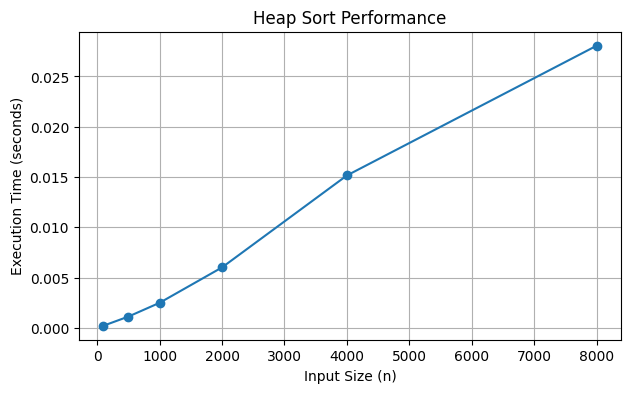

In [5]:
#Heap-Based Algorithms
#Heap sort
import time
import random
import matplotlib.pyplot as plt


def heapify(arr, n, i):
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)


def heap_sort(arr):
    n = len(arr)


    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)


    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)

    return arr



arr = [12, 17, 5, 21, 8, 34, 16, 1]

print("Original:", arr)
print("Sorted:", heap_sort(arr.copy()))

sizes = [100, 500, 1000, 2000, 4000, 8000]
times = []

for n in sizes:
    arr = random.sample(range(n * 2), n)

    start = time.perf_counter()
    heap_sort(arr)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Heap Sort Performance")
plt.grid(True)
plt.show()

Original: aaabbc
Rearranged: ababac


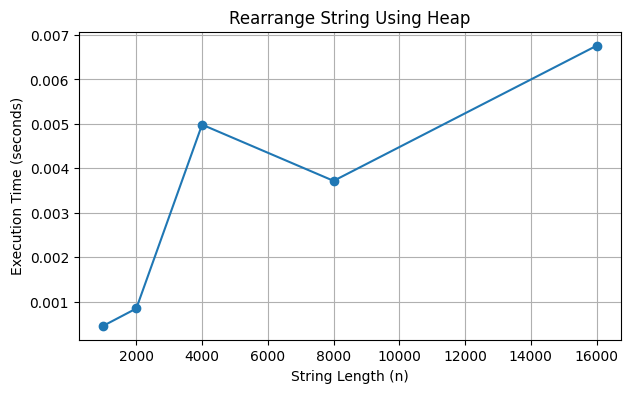

In [6]:
#Rearrange string so no two adjacent characters are same
import heapq
from collections import Counter
import time
import random
import string
import matplotlib.pyplot as plt


def rearrange_string(s):

    count = Counter(s)

    heap = []

    for char, freq in count.items():
        heapq.heappush(heap, (-freq, char))

    result = []
    previous = None

    while heap:

        freq, char = heapq.heappop(heap)

        if char == previous:

            if not heap:
                return "Not possible"

            freq2, char2 = heapq.heappop(heap)

            result.append(char2)
            previous = char2

            freq2 += 1

            if freq2 < 0:
                heapq.heappush(heap, (freq2, char2))

            heapq.heappush(heap, (freq, char))

        else:

            result.append(char)
            previous = char

            freq += 1

            if freq < 0:
                heapq.heappush(heap, (freq, char))

    return ''.join(result)



s = "aaabbc"

print("Original:", s)
print("Rearranged:", rearrange_string(s))



sizes = [1000, 2000, 4000, 8000, 16000]
times = []

characters = "abcdef"

for n in sizes:

    s = ''.join(random.choice(characters) for _ in range(n))

    start = time.perf_counter()
    rearrange_string(s)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("String Length (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Rearrange String Using Heap")
plt.grid(True)
plt.show()

Array: [12, 3, 5, 7, 4, 19, 26, 1, 8]
Kth smallest: 5


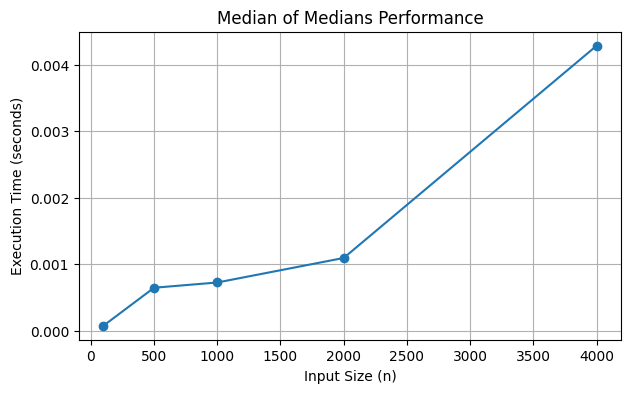

In [7]:
#Kth smallest element using Median-of-Medians
import random
import time
import matplotlib.pyplot as plt


def median_of_medians(arr, k):

    if len(arr) <= 5:
        arr.sort()
        return arr[k - 1]

    groups = []

    for i in range(0, len(arr), 5):
        group = arr[i:i + 5]
        group.sort()
        groups.append(group)

    medians = []

    for group in groups:
        medians.append(group[len(group) // 2])

    if len(medians) <= 5:
        medians.sort()
        pivot = medians[len(medians) // 2]
    else:
        pivot = median_of_medians(
            medians,
            (len(medians) + 1) // 2
        )

    smaller = []
    equal = []
    larger = []

    for x in arr:

        if x < pivot:
            smaller.append(x)

        elif x == pivot:
            equal.append(x)

        else:
            larger.append(x)

    if k <= len(smaller):

        return median_of_medians(smaller, k)

    elif k <= len(smaller) + len(equal):

        return pivot

    else:

        new_k = k - len(smaller) - len(equal)

        return median_of_medians(larger, new_k)



arr = [12, 3, 5, 7, 4, 19, 26, 1, 8]

k = 4

print("Array:", arr)
print("Kth smallest:", median_of_medians(arr, k))



sizes = [100, 500, 1000, 2000, 4000]
times = []

for n in sizes:

    arr = random.sample(range(n * 2), n)
    k = n // 2

    start = time.perf_counter()
    median_of_medians(arr, k)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Median of Medians Performance")
plt.grid(True)
plt.show()


Merged array: [1, 2, 3, 4, 5, 6, 7, 8, 9]


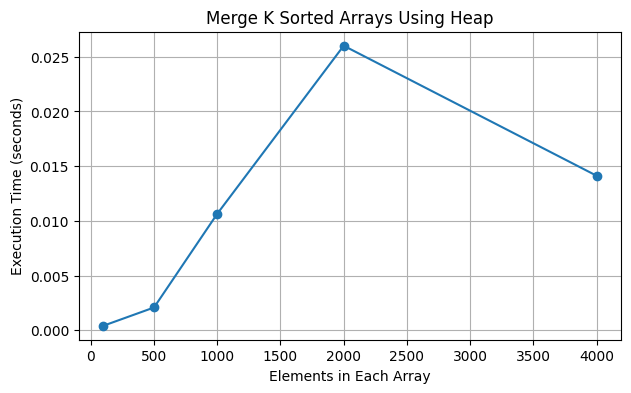

In [8]:
#Merge k sorted arrays using heap
import heapq
import time
import matplotlib.pyplot as plt


def merge_k_arrays(arrays):

    heap = []
    result = []


    for i in range(len(arrays)):

        if len(arrays[i]) > 0:
            heapq.heappush(
                heap,
                (arrays[i][0], i, 0)
            )

    while heap:

        value, array_index, element_index = heapq.heappop(heap)

        result.append(value)

        next_index = element_index + 1

        if next_index < len(arrays[array_index]):

            next_value = arrays[array_index][next_index]

            heapq.heappush(
                heap,
                (next_value, array_index, next_index)
            )

    return result



arrays = [
    [1, 4, 7],
    [2, 5, 8],
    [3, 6, 9]
]

print("Merged array:", merge_k_arrays(arrays))



sizes = [100, 500, 1000, 2000, 4000]
times = []

k = 5

for n in sizes:

    arrays = []

    for i in range(k):
        arr = list(range(i, i + n))
        arrays.append(arr)

    start = time.perf_counter()
    merge_k_arrays(arrays)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Elements in Each Array")
plt.ylabel("Execution Time (seconds)")
plt.title("Merge K Sorted Arrays Using Heap")
plt.grid(True)
plt.show()